## Cerebellar grey matter volume extractor

Using SUITPy

In [2]:
# Import packages
from nilearn import plotting as npl
import SUITPy as suit
import SUITPy.atlas as atlas
import nibabel as nib
import ants
import matplotlib.pyplot as plt
import numpy as np

import pandas as pd

from pathlib import Path # for saving file name

In [3]:
"""
Modified SUITPy.normalization function: added args jac_log = False, jac_geom = True
Make sure to also add the template (in folder "templates")
"""
import sys
sys.path.append('/Users/medha/Desktop/USRI 2026/suitpy edits')

from normalization import normalize # import from above folder

import SUITPy.normalization as modif

modif.normalize = normalize # SUITPy.normalization normalize function now uses local (edited) normalize function

In [4]:
t1_img = 'CU_2310/W4/CU_2310_W4_T1.nii'
#gm_img = 'smarts_cerebellum/anatomicals/UZP_1008/W52/c1UZP_1008_W52_T1w_LPI.nii'
file_name = Path(t1_img).stem

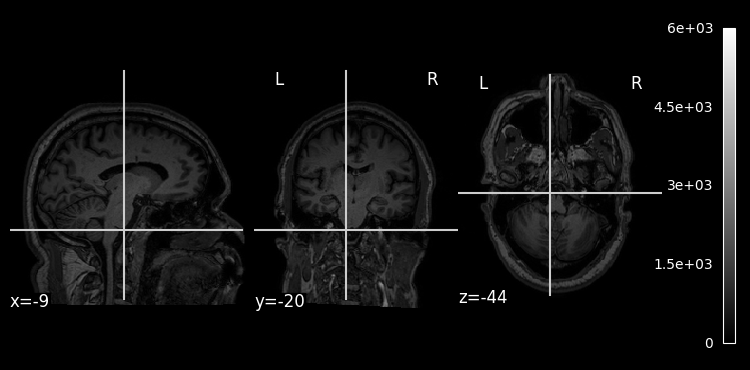

In [5]:
npl.plot_anat(t1_img)

In [6]:
# new folder for each individual's outputs
new_path = Path('gmv_results') / file_name
new_path.mkdir(parents = True)

In [7]:
# 1. isolation module

"""
`isolate` function generates an isolation MASK for cerebellum; registration done by function
input: T1-weighted scan
output: cerebellar mask (as ANTsImage)
"""
mask = suit.isolate(t1_img, result_folder = new_path)
mask_path = new_path/f'{file_name}_cerebellum_dseg.nii.gz'

"""
# visualize results
img = nib.load(t1_img)
mask = nib.load(str(mask_path))
npl.plot_roi(mask_img, img)
"""

preprocessing CU_2310/W4/CU_2310_W4_T1.nii
isolating cerebellum using UNet model
postprocessing
saving results to CU_2310_W4_T1_cerebellum_dseg.nii.gz


'\n# visualize results\nimg = nib.load(t1_img)\nmask = nib.load(str(mask_path))\nnpl.plot_roi(mask_img, img)\n'

# perform check

In [13]:
display(t1_img)
#display(gm_img)
display(mask_path)

'CU_2310/W4/CU_2310_W4_T1.nii'

PosixPath('gmv_results/CU_2310_W4_T1/CU_2310_W4_T1_cerebellum_dseg.nii.gz')

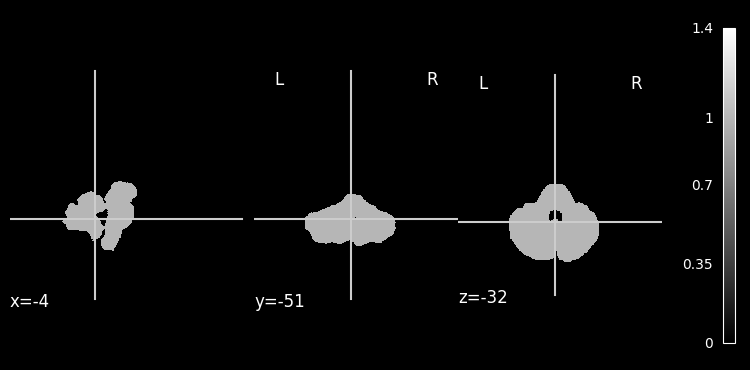

In [9]:
npl.plot_anat(str(mask_path))

# continue

In [ ]:
# 2. normalization module

"""
Input: cerebellar mask (from isolation); source image
Output: (1) normalized cerebellum: anatomical in SUIT space; (2) deformation field
Normalizes to the SUIT cerebellar template
"""

results = modif.normalize(source_file = str(t1_img),
                         mask_file = str(mask_path),
                         space = 'SUIT', # SUIT is default
                         write_jacobian_determinant=True, # save jac det
                         write_ants_transform = True, # forward and inverse ANTs transforms
                         write_normalized = True, # save template space
                         result_folder = new_path,
                         jac_log = False,
                         jac_geom = True, # robust to different image orientations (e.g. non-axial)
                         verbose = 1)

ValueError: images do not occupy same physical space

In [12]:
help(ants.image_physical_space_consistency)

Help on function image_physical_space_consistency in module ants.utils.consistency:

image_physical_space_consistency(image1, image2, tolerance=0.01, datatype=False)
    Check if two or more ANTsImage objects occupy the same physical space

    ANTsR function: `antsImagePhysicalSpaceConsistency`

    Arguments
    ---------
    *images : ANTsImages
        images to compare

    tolerance : float
        tolerance when checking origin and spacing

    data_type : boolean
        If true, also check that the image data types are the same

    Returns
    -------
    boolean
        true if images share same physical space, false otherwise



In [4081]:
"""
Reslice module:
`reslice_image` deforms images aligned to indiv anat img into SUIT space
So use the isolation mask (isolation) and deformation file (normalization)
"""

'\nReslice module:\n`reslice_image` deforms images aligned to indiv anat img into SUIT space\nSo use the isolation mask (isolation) and deformation file (normalization)\n'

In [4082]:
# 3. reslice image

"""
Input: cerebellar gm (c1), deformation image, cerebellar mask
Output: resliced image
"""
# (anatomical) grey matter in suit space
output_img = suit.reslice_image(source_image = gm_img , # want grey matter mapped from naive space to suit space
                                deformation = results['fwd_deformation'],
                                mask = str(mask_path) # nifti, str
)

nib.save(output_img, new_path/f'output_{file_name}.nii') # grey matter probability

# optional plotting
#npl.plot_anat(output_img, cut_coords=(-1, -58, -36)) # specify 3-dim coordinates


In [4083]:
# calculate gmv in suit space
voxel_dim = output_img.header.get_zooms()[:3] # voxel volume DIMENSIONS, also check in fsleyes
voxel_vol = np.prod(voxel_dim) # volume of each voxel

# mask GM with isolated cerebellar mask
gm_data = output_img.get_fdata() # grey matter in suit space
jac_det_img = nib.load(results['jacobian_determinant']) # nifti
jac_det = jac_det_img.get_fdata() # numpy array

gmv = gm_data*jac_det*voxel_vol

In [4084]:
gmv_img = nib.Nifti1Image(gmv, output_img.affine)
nib.save(gmv_img, new_path/f'gmv_img_{file_name}.nii')

https://www.nature.com/articles/s41467-024-52371-w
High boundary symmetry between left and right hemispheres in motor regions (esp hand region M3), so symmetric atlas is appropriate. However, other regions showed low symmetry (e.g. social-linguistic-spatial regions), so asymmetric map more appropriate.

So will use asymmetric since may want to investigate other regions.

Using medium granulity (32-region).

In [4085]:
# 4. dataframe for resliced image (choose an atlas)

# in this case, using Nettekoven_2024 with asymmetric 32-region map (for hand function region, M3)
atlas.fetch_atlas('Nettekoven_2024')
df = atlas.summarize_data(gmv_img, space = 'SUIT', # use same space as normalization
                     stats = ['nanmean'],
                     atlas = 'Nettekoven_2024', maps = 'atl-NettekovenAsym32')
df['gmv'] = df['nanmean']*(df['size']/voxel_vol) # total volume = sum of gmv/voxel
 # to get the sum: size is volume of region (mm^3, voxel), so number of voxels is size / voxel volume

df.rename(columns={'nanmean': 'avg_gmv'}, inplace = True)
df['image_name'] = f'gmv_img_{file_name}.nii' # file name for each
#df.drop(columns = 'nanmean', inplace = True)
df.head(5)

,image,image_name,frame,region,regionname,size,atlas,map,space,avg_gmv,gmv
0,1,gmv_img_UZP_1008_W52_T1w_LPI.nii,0,1,M1L,1699.0,Nettekoven_2024,atl-NettekovenAsym32,SUIT,0.593836,1008.928179
1,1,gmv_img_UZP_1008_W52_T1w_LPI.nii,0,2,M2L,4252.0,Nettekoven_2024,atl-NettekovenAsym32,SUIT,0.638578,2715.235630
2,1,gmv_img_UZP_1008_W52_T1w_LPI.nii,0,3,M3L,9115.0,Nettekoven_2024,atl-NettekovenAsym32,SUIT,0.629589,5738.701719
3,1,gmv_img_UZP_1008_W52_T1w_LPI.nii,0,4,M4L,2329.0,Nettekoven_2024,atl-NettekovenAsym32,SUIT,0.561676,1308.144144
4,1,gmv_img_UZP_1008_W52_T1w_LPI.nii,0,5,A1L,717.0,Nettekoven_2024,atl-NettekovenAsym32,SUIT,0.754140,540.718042


In [4086]:
df.to_csv('gmv_results/gmv_atlas.tsv', mode = 'a', index = False, header = False, sep = '\t') # write as tsv
# header only for first run

In [4087]:
participants_file = 'smarts_cerebellum/participants.tsv'
participants_df = pd.read_csv(str(participants_file), sep = '\t')
gmv_df = pd.read_csv('gmv_results/gmv_atlas.tsv', sep = '\t')

# EDIT

In [4088]:
# EDIT THIS EACH TIME
name = 'gmv_img_UZP_1008_W52_T1w_LPI.nii'

gmv_df=gmv_df[gmv_df['image_name']==name]

In [4089]:
# only run this the first time
gmv_df['ID'] = ''
gmv_df['Centre'] = ''
gmv_df['week'] = ''
gmv_df['age'] = ''
gmv_df['Gender'] = ''
gmv_df['isPatient'] = ''
gmv_df['LesionSide'] = ''
gmv_df['LesionLocation'] = ''
gmv_df['RefT1'] = ''
gmv_df['handedness'] = ''

# EDIT

In [4090]:
# row: write to new tsv
row = gmv_df['image_name'] == name

# other_row: get info from previous tsv ('participants.tsv')
other_row = participants_df.loc[(participants_df['ID'] == 1008) & (participants_df['Centre'] == 'UZP') & (participants_df['Week'] == 'W52')].iloc[0]

In [4091]:
other_row

SN                          210
ID                         1008
Centre                      UZP
Week                        W52
week                         52
RefT1                       W0 
numrun                        8
nslices                      31
Hand                          b
LesionSide                none 
lesionside                    0
LesionLocation      none       
lesionlocation                0
age                          63
Gender                        M
handedness                    2
isPatient                     0
glm                           1
surf_quality                  0
surfmvpa                      1
include1                      1
lesiondef                     0
behavior_missing              0
behavior_blocks               8
has_mvc                       1
DTImap_missing                1
CentreNo                      3
machine                 eberlot
Name: 209, dtype: object

In [4092]:
gmv_df.loc[row, 'ID'] = str(f'{other_row['ID']}')
gmv_df.loc[row, 'Centre'] = other_row['Centre']
gmv_df.loc[row, 'week'] = str(f'{other_row['week']}')
#gmv_df.loc[row, 'week'] = '1'
gmv_df.loc[row, 'RefT1'] = other_row['RefT1']
gmv_df.loc[row, 'age'] = str(f'{other_row['age']}')
gmv_df.loc[row, 'Gender'] = other_row['Gender']
gmv_df.loc[row, 'isPatient'] = str(f'{other_row['isPatient']}')
gmv_df.loc[row, 'LesionSide'] = other_row['LesionSide']
gmv_df.loc[row, 'LesionLocation'] = other_row['LesionLocation']
gmv_df.loc[row, 'handedness'] = str(f'{other_row['handedness']}')

In [4093]:
gmv_df.to_csv('gmv_results/gmv_atlas_full.tsv', sep = '\t', mode = 'a', index = False, header = False)

# IGNORE

In [ ]:
#df.to_csv('gmv_results/gmv_atlas.tsv', mode = 'a', index = True, header = False, sep = '\t')
# header only for first run

In [674]:
"""
import pandas as pd
participants_file = 'smarts_cerebellum/participants.tsv'
participants_df = pandas.read_csv(str(participants_file), sep = '\t')

df_csv = pd.read_csv('gmv_results/gmv_atlas.csv')
df_csv.to_csv('gmv_results/gmv_atlas.tsv', sep = '\t', index = False)
"""

"\nimport pandas as pd\nparticipants_file = 'smarts_cerebellum/participants.tsv'\nparticipants_df = pandas.read_csv(str(participants_file), sep = '\t')\n\ndf_csv = pd.read_csv('gmv_results/gmv_atlas.csv')\ndf_csv.to_csv('gmv_results/gmv_atlas.tsv', sep = '\t', index = False)\n"

In [1219]:
participants_file = 'smarts_cerebellum/participants.tsv'
participants_df = pd.read_csv(str(participants_file), sep = '\t')
gmv_df = pd.read_csv('gmv_results/gmv_atlas.tsv', sep = '\t')
full_df = pd.read_csv('gmv_results/gmv_atlas_full.tsv', sep = '\t')

In [ ]:

# only run this the first time
gmv_df['ID'] = ''
gmv_df['Centre'] = ''
gmv_df['Week'] = ''
gmv_df['age'] = ''
gmv_df['Gender'] = ''
gmv_df['isPatient'] = ''
gmv_df['LesionSide'] = ''
gmv_df['LesionLocation'] = ''
gmv_df['RefT1'] = ''
gmv_df['handedness'] = ''


In [1222]:
full_df

,Unnamed: 0.1,Unnamed: 0,image,image_name,frame,region,regionname,size,atlas,map,...,ID,Centre,Week,age,Gender,isPatient,LesionSide,LesionLocation,RefT1,handedness
0,0,0,1,gmv_img_CU_2310_W0_T1.nii,0,1,M1L,1699.0,Nettekoven_2024,atl-NettekovenAsym32,...,2310,CU,W0,57,M,1,left,subcortical,W0,2
1,1,1,1,gmv_img_CU_2310_W0_T1.nii,0,2,M2L,4252.0,Nettekoven_2024,atl-NettekovenAsym32,...,2310,CU,W0,57,M,1,left,subcortical,W0,2
2,2,2,1,gmv_img_CU_2310_W0_T1.nii,0,3,M3L,9115.0,Nettekoven_2024,atl-NettekovenAsym32,...,2310,CU,W0,57,M,1,left,subcortical,W0,2
3,3,3,1,gmv_img_CU_2310_W0_T1.nii,0,4,M4L,2329.0,Nettekoven_2024,atl-NettekovenAsym32,...,2310,CU,W0,57,M,1,left,subcortical,W0,2
4,4,4,1,gmv_img_CU_2310_W0_T1.nii,0,5,A1L,717.0,Nettekoven_2024,atl-NettekovenAsym32,...,2310,CU,W0,57,M,1,left,subcortical,W0,2
5,5,5,1,gmv_img_CU_2310_W0_T1.nii,0,6,A2L,9619.0,Nettekoven_2024,atl-NettekovenAsym32,...,2310,CU,W0,57,M,1,left,subcortical,W0,2
6,6,6,1,gmv_img_CU_2310_W0_T1.nii,0,7,A3L,3474.0,Nettekoven_2024,atl-NettekovenAsym32,...,2310,CU,W0,57,M,1,left,subcortical,W0,2
7,7,7,1,gmv_img_CU_2310_W0_T1.nii,0,8,D1L,5153.0,Nettekoven_2024,atl-NettekovenAsym32,...,2310,CU,W0,57,M,1,left,subcortical,W0,2
8,8,8,1,gmv_img_CU_2310_W0_T1.nii,0,9,D2L,2640.0,Nettekoven_2024,atl-NettekovenAsym32,...,2310,CU,W0,57,M,1,left,subcortical,W0,2
9,9,9,1,gmv_img_CU_2310_W0_T1.nii,0,10,D3L,9941.0,Nettekoven_2024,atl-NettekovenAsym32,...,2310,CU,W0,57,M,1,left,subcortical,W0,2


In [1224]:
participants_df

,SN,ID,Centre,Week,week,RefT1,numrun,nslices,Hand,LesionSide,...,surf_quality,surfmvpa,include1,lesiondef,behavior_missing,behavior_blocks,has_mvc,DTImap_missing,CentreNo,machine
0,1,2310,CU,W4,4,W0,8,35,b,left,...,0,1,1,1,0,8,0,0,1,naveed
1,2,2310,CU,W12,12,W0,8,35,b,left,...,0,1,1,1,0,8,1,0,1,naveed
2,3,2310,CU,W24,24,W0,8,35,b,left,...,0,1,1,1,0,8,1,0,1,naveed
3,4,2310,CU,W52,52,W0,8,35,b,left,...,0,1,1,1,3,0,1,0,1,naveed
4,5,2538,CU,W1,1,W0,8,35,b,right,...,0,1,1,1,0,8,1,0,1,naveed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
205,206,1008,UZP,W1,1,W0,8,31,b,none,...,0,1,1,0,0,8,1,1,3,eberlot
206,207,1008,UZP,W4,4,W0,8,31,b,none,...,0,1,1,0,0,8,1,1,3,eberlot
207,208,1008,UZP,W12,12,W0,8,31,b,none,...,0,1,1,0,0,8,1,1,3,eberlot
208,209,1008,UZP,W24,24,W0,8,31,b,none,...,0,1,1,0,0,8,1,1,3,eberlot


In [1231]:
row = gmv_df['image_name'] == 'gmv_img_CU_2310_W4_T1.nii'
other_row = participants_df.loc[(participants_df['ID'] == 2310)].iloc[0]

In [1232]:
other_row

SN                            1
ID                         2310
Centre                      CU 
Week                        W4 
week                          4
RefT1                       W0 
numrun                        8
nslices                      35
Hand                          b
LesionSide                left 
lesionside                    1
LesionLocation      subcortical
lesionlocation                2
age                          57
Gender                        M
handedness                    2
isPatient                     1
glm                           1
surf_quality                  0
surfmvpa                      1
include1                      1
lesiondef                     1
behavior_missing              0
behavior_blocks               8
has_mvc                       0
DTImap_missing                0
CentreNo                      1
machine                 naveed 
Name: 0, dtype: object

In [1233]:
gmv_df.loc[row, 'ID'] = str(f'{other_row['ID']}')
gmv_df.loc[row, 'Centre'] = other_row['Centre']
gmv_df.loc[row, 'RefT1'] = other_row['RefT1']
gmv_df.loc[row, 'age'] = str(f'{other_row['age']}')
gmv_df.loc[row, 'Gender'] = other_row['Gender']
gmv_df.loc[row, 'isPatient'] = str(f'{other_row['isPatient']}')
gmv_df.loc[row, 'LesionSide'] = other_row['LesionSide']
gmv_df.loc[row, 'LesionLocation'] = other_row['LesionLocation']
gmv_df.loc[row, 'handedness'] = str(f'{other_row['handedness']}')

In [1234]:
gmv_df.loc[row, 'Week'] = 'W4'

In [1235]:
gmv_df.to_csv('gmv_results/gmv_atlas_full.tsv', sep = '\t')

In [ ]:
df.to_csv('gmv_results/gmv_atlas.tsv', mode = 'a', index = True, header = False, sep = '\t')

In [ ]:
#gmv_df.drop(columns = 'Unnamed: 0', inplace = True)